# Using the KERAS library to build a MLP

In [ ]:
# Run this block only if you're using the notebook on a local machine
! pip install numpy
! pip install tensorflow
! pip install matplotlib

In [1]:
# Libraries import
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Model / data parameters
num_classes = 10 

# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(type(x_train))
print(x_train.shape)

print(type(y_train))
print(y_train.shape)

<class 'numpy.ndarray'>
(60000, 28, 28)
<class 'numpy.ndarray'>
(60000,)


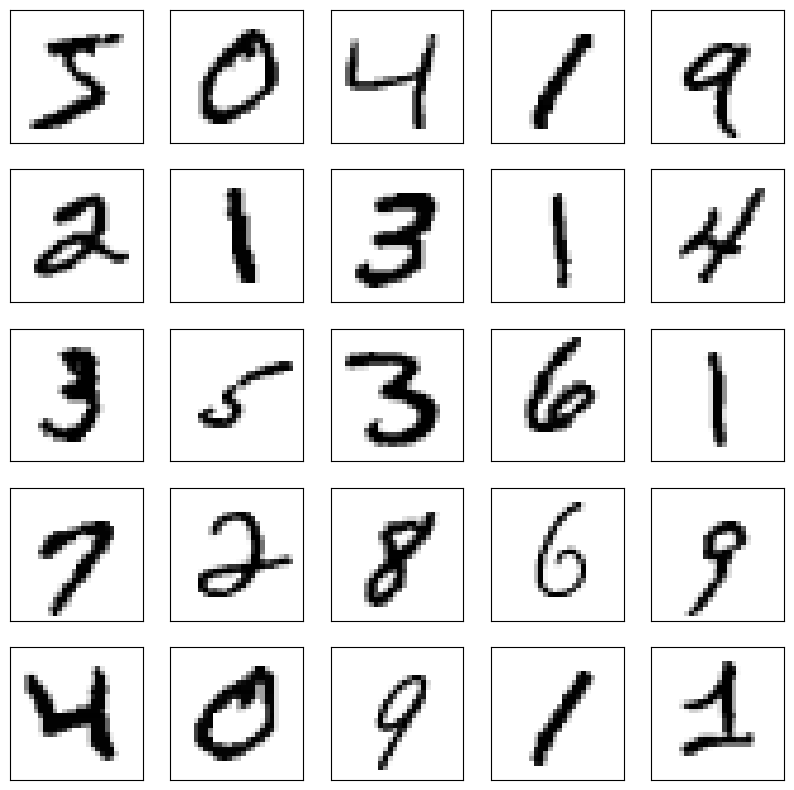

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i,image in enumerate(x_train[0:25]):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(image, cmap=plt.cm.binary)
plt.show()

In [5]:
# Convert each image of size 28*28 (2d-vector) into a 1D vector of 1*784
# Reshape the data - MLPs do not understand such things as '2D'.
# Reshape to 28 x 28 pixels = 784 features

feature_vector_length = 784
x_train = x_train.reshape(x_train.shape[0], feature_vector_length)
x_test = x_test.reshape(x_test.shape[0], feature_vector_length)

print(x_train.shape)
print(x_test.shape)
print(x_train[0])

(60000, 784)
(10000, 784)
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 

In [5]:
# Normalization
x_train = x_train / 255
x_test = x_test / 255

print(x_train[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

**KERAS library**

- **Keras sequential documentation ->** [link](https://keras.io/guides/sequential_model/)
- **Keras documentation for Dense layer documentation ->** [link](https://keras.io/api/layers/core_layers/dense/)

In [16]:
# Create the model using KERAS
model = keras.Sequential()

# Add the hidden layers
model.add(layers.Input(shape=(feature_vector_length,)))
model.add(layers.Dense(512, activation= "relu"))
model.add(layers.Dense(256, activation = "relu"))
model.add(layers.Dense(num_classes, activation= "softmax"))


In [17]:
# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

**Softmax**

The softmax function is a function that turns a vector of K real values into a vector of K real values that sum to 1. The input values can be positive, negative, zero, or greater than one, but the softmax transforms them into values between 0 and 1, so that they can be interpreted as probabilities. If one of the inputs is small or negative, the softmax turns it into a small probability, and if an input is large, then it turns it into a large probability, but it will always remain between 0 and 1. (The high value will have the higher probability than other values.)


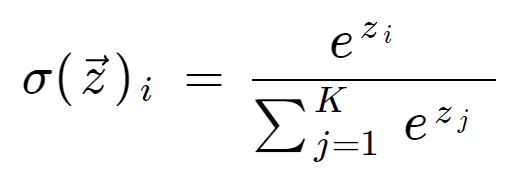

Many multi-layer neural networks end in a penultimate layer which outputs real-valued scores that are not conveniently scaled and which may be difficult to work with. Here the softmax is very useful because it converts the scores to a normalized probability distribution, which can be displayed to a user or used as input to other systems. For this reason it is usual to append a softmax function as the final layer of the neural network.

More info : https://deepai.org/machine-learning-glossary-and-terms/softmax-layer

In [9]:
# Let's test the softmax
from scipy.special import softmax

x = [5, 6, -3, 5, -0.7 ,4]
print("Probs:", softmax(x))
print("Sum:", np.sum(softmax(x)))

Probs: [1.96469726e-01 5.34060086e-01 6.59082506e-05 1.96469726e-01
 6.57380917e-04 7.22771730e-02]
Sum: 1.0


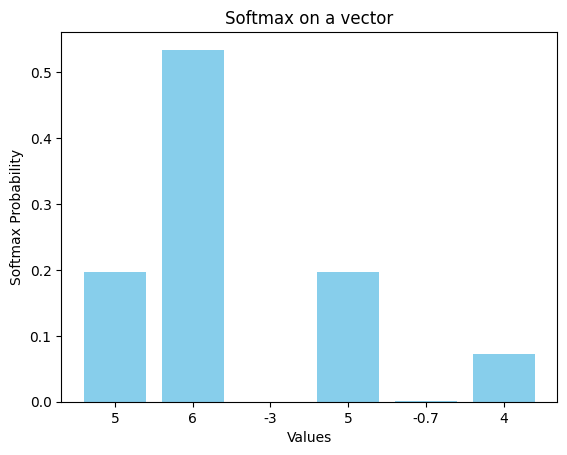

In [10]:
# Let's plot the softmax probability distribution
plt.bar(range(len(x)), softmax(x), color='skyblue')
plt.xlabel('Values')
plt.ylabel('Softmax Probability')
plt.title('Softmax on a vector')
plt.xticks(range(len(x)), x)
plt.show()

**Cross-Entropy**

It is a measure of the degree of dissimilarities between two probability distribution.
Cross-entropy loss, or log loss, measures the performance of a classification model whose output is a probability value between 0 and 1. Cross-entropy loss increases as the predicted probability diverges from the actual label. So predicting a probability of .012 when the actual observation label is 1 would be bad and result in a high loss value. A perfect model would have a log loss of 0.

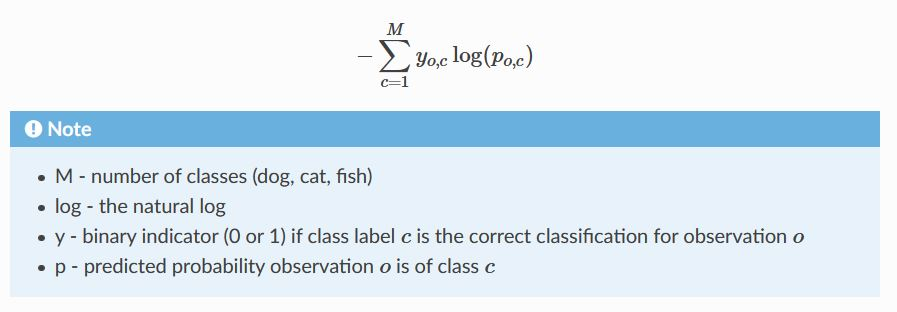

**COMPILE and FIT the model**

**Probabilistic losses documentation ->** [link](https://keras.io/api/losses/probabilistic_losses/)

**Compile function documentation ->** [link](https://keras.io/api/models/model_training_apis/)

In [18]:
# Complile and fit
batch_size = 128
epochs = 15

model.compile(loss ="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train,y_train, batch_size= batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8388 - loss: 6.8747 - val_accuracy: 0.9357 - val_loss: 0.3505
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9438 - loss: 0.2571 - val_accuracy: 0.9428 - val_loss: 0.2741
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9587 - loss: 0.1571 - val_accuracy: 0.9577 - val_loss: 0.2150
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9704 - loss: 0.1119 - val_accuracy: 0.9653 - val_loss: 0.1843
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9733 - loss: 0.0930 - val_accuracy: 0.9658 - val_loss: 0.1822
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9768 - loss: 0.0869 - val_accuracy: 0.9710 - val_loss: 0.1688
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9769 - loss: 0.0856 - val_accuracy: 0.9720 - val_loss: 0.1409
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9804 - loss: 0.0694 - val_accura

In [12]:
# Evaluate
score = model.evaluate(x_test, y_test, verbose=False)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# Predict class
predict_x = model.predict(x_test[:1], verbose=False) 
classes_x = np.argmax(predict_x, axis=1)
print("Predictions:", predict_x)
print("Sum:", np.sum(predict_x))
print("Class:", classes_x)

Test loss: 3.3653104305267334
Test accuracy: 0.8578000068664551
Predictions: [[0.0000000e+00 0.0000000e+00 0.0000000e+00 4.4881551e-07 0.0000000e+00
  0.0000000e+00 0.0000000e+00 9.9999952e-01 3.0465052e-36 4.8057434e-24]]
Sum: 1.0
Class: [7]


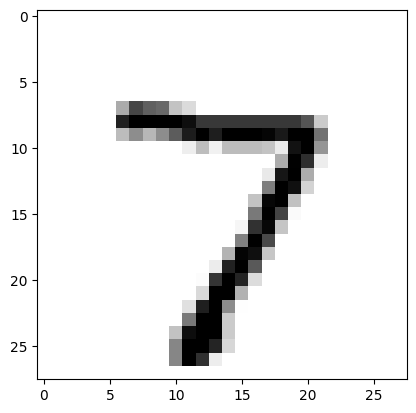

In [13]:
# Let's draw the image and check
import matplotlib.pyplot as plt
x_test_vis = x_test[0].reshape(28, 28)
_ = plt.imshow(x_test_vis, cmap = plt.cm.binary)

In [14]:
# Check history content
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

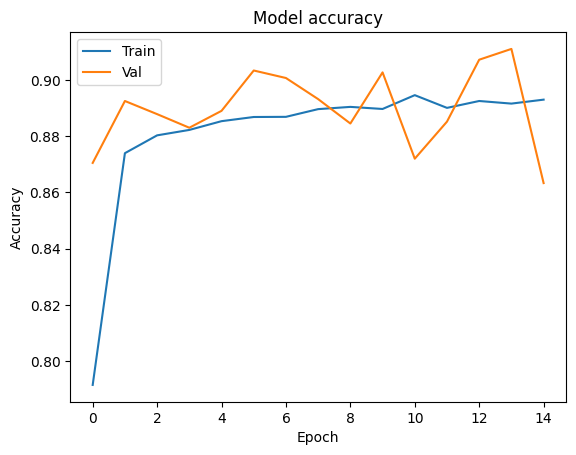

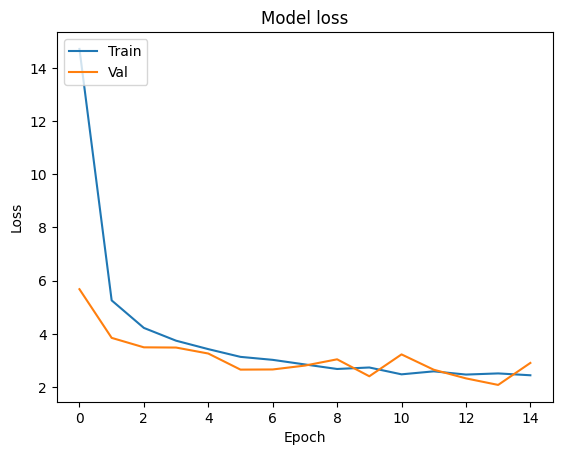

In [15]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

**Homeworks**

- Implement a MLP using keras to classify a different emnist dataset
- Documentation [link](https://www.nist.gov/itl/products-and-services/emnist-dataset)

In [ ]:
! pip install emnist

In [ ]:
from emnist import list_datasets
list_datasets()

In [ ]:
from emnist import extract_training_samples

images, labels = extract_training_samples('letters')
print(images.shape)
print(labels.shape)
print(type(images))
print(np.unique(labels).shape)
print(len(np.unique(labels)))